In [5]:
library(Seurat)
library(tidyverse)
library(RColorBrewer)
library(viridisLite)
library(EnhancedVolcano)
library(scCustomize)
library(ggplot2)
library(scales)
library(RColorBrewer)
library(viridisLite)
library(ComplexHeatmap)
library(circlize)
library(ggpubr)
library(rstatix)
library(patchwork)
library(car)     
library(emmeans)
library(MAST)
library(survival)
library(survminer)
source("/diskmnt/Users2/epeng/Projects/mCRC/scripts/jupyter_support_functions.R")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to fo

# Load data

In [1]:
output_dir = '/diskmnt/Projects/MetNet_analysis/Colorectal/Revision/Neuroendocrine_version'

In [2]:
tumor_rds_path = '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/57_Integrated_normalized_mCRC_snRNA_noDB_v7_epithelial_clean4.rds'
tumor_obj = readRDS(tumor_rds_path)
tumor_obj

An object of class Seurat 
71822 features across 225685 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: SCT
 8 dimensional reductions calculated: pca, umap.rna, integrated.scvi, mCRCv4_umap.scvi, mCRCv5_umap.scvi, mCRCv6_umap.scvi, epithelial_umap.scvi, epithelial_umap2.scvi

In [3]:
cell_type_file = '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/mCRC_57_samples_clean3_metadata_cell_type_all_20250505.csv'
cell_type = read.table(cell_type_file, header = TRUE, sep=',', row.name=1)
head(cell_type, 3)

,broad_cell_type,cell_type_all,cell_type_all2,cell_type_xenium
,<chr>,<chr>,<chr>,<chr>
HT112C1-T1_AAACATGCAATAATCC-1,T cell,CD4 T,CD4_Resting_T,CD4_Resting_T
HT112C1-T1_AAACCAACAGTTTCTC-1,Tumor,APCDD1+ tumor,APCDD1_CRC,APCDD1_CRC
HT112C1-T1_AAACCGCGTAAGCTTG-1,Fibroblast,Fibroblast,mesenchymal_doublets,mesenchymal_doublets


In [6]:
tumor_obj <- AddMetaData(tumor_obj, cell_type, col.name = c('broad_cell_type', 'cell_type_all', 'cell_type_all2', 'cell_type_xenium'))
head(tumor_obj@meta.data, 3)

,orig.ident,Patient_ID,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,seurat_clusters,S.Score,G2M.Score,⋯,epithelial_cluster_sub6,epi_clusters_0.1,epithelial_cluster_sub0,epithelial_cluster_sub2,epithelial_cluster_sub3,epi_cell_type,broad_cell_type,cell_type_all,cell_type_all2,cell_type_xenium
,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<dbl>,<dbl>,⋯,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HT112C1-T1_AAACCAACAGTTTCTC-1,HT112C1-T1,HT112C1,7056,3049,0.001275510,3127,1966,2,-0.1390377,-0.07635363,⋯,0_0,2,2,2_0,2_0,APCDD1+ tumor,Tumor,APCDD1+ tumor,APCDD1_CRC,APCDD1_CRC
HT112C1-T1_AAACCGCGTGCGCAAT-1,HT112C1-T1,HT112C1,9842,4221,0.018288966,2752,1849,1,0.4241602,0.30120090,⋯,1_0,1,1,1,1,Proliferative tumor,Tumor,Proliferative tumor,Canonical_CRC_Intestine_Proliferation,Canonical_CRC_Intestine_Proliferation
HT112C1-T1_AAACCGCGTTAACGAT-1,HT112C1-T1,HT112C1,10719,4441,0.001119507,2816,1925,1,0.4051472,0.24396604,⋯,1_0,1,1,1,1,Proliferative tumor,Tumor,Proliferative tumor,Canonical_CRC_Intestine_Proliferation,Canonical_CRC_Intestine_Proliferation


In [7]:
tumor_obj <- subset(tumor_obj, !is.na(cell_type_all2))
tumor_obj

Warning message:
“Removing 523 cells missing data for vars requested”


An object of class Seurat 
71822 features across 225162 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: SCT
 8 dimensional reductions calculated: pca, umap.rna, integrated.scvi, mCRCv4_umap.scvi, mCRCv5_umap.scvi, mCRCv6_umap.scvi, epithelial_umap.scvi, epithelial_umap2.scvi

In [8]:
unique(tumor_obj$cell_type_all2)

[1] "APCDD1_CRC"                           
 [2] "Canonical_CRC_Intestine_Proliferation"
 [3] "Canonical_CRC_Intestine"              
 [4] "Non_Canonical_CRC_1"                  
 [5] "Canonical_CRC_Stem"                   
 [6] "Canonical_CRC_Stem_Proliferation"     
 [7] "Enteroendocrine-like cells"           
 [8] "Goblet cells"                         
 [9] "Transit-amplifying cells"             
[10] "Enterocytes"                          
[11] "Stem cells"                           
[12] "Tuft cells"

# Cell typing

In [9]:
Idents(tumor_obj) = "cell_type_all2"
tumor_obj = FindSubCluster(object = tumor_obj,
                       cluster = 'Enteroendocrine-like cells',
                       graph.name = 'RNA_snn',
                       subcluster.name = "cell_type_all3",
                       resolution = 0.1,
                       algorithm = 1
                      )
unique(tumor_obj$cell_type_all3)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 720
Number of edges: 24455

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9219
Number of communities: 2
Elapsed time: 0 seconds


[1] "APCDD1_CRC"                           
 [2] "Canonical_CRC_Intestine_Proliferation"
 [3] "Canonical_CRC_Intestine"              
 [4] "Non_Canonical_CRC_1"                  
 [5] "Canonical_CRC_Stem"                   
 [6] "Canonical_CRC_Stem_Proliferation"     
 [7] "Enteroendocrine-like cells_0"         
 [8] "Enteroendocrine-like cells_1"         
 [9] "Goblet cells"                         
[10] "Transit-amplifying cells"             
[11] "Enterocytes"                          
[12] "Stem cells"                           
[13] "Tuft cells"

In [10]:
unique(tumor_obj$broad_cell_type)

[1] "Tumor"                 "Colon epithelial cell"

In [11]:
tumor_obj@meta.data <- tumor_obj@meta.data %>% 
                       mutate(cell_type_all3 = case_when(
                                  cell_type_all3 == 'Non_Canonical_CRC_1' ~ 'CMETS',
                                  cell_type_all3 == 'Enteroendocrine-like cells_0' ~ 'Neuroendocrine-like tumor',
                                  cell_type_all3 == 'Enteroendocrine-like cells_1' ~ 'Neuroendocrine cells',
                                  TRUE ~ cell_type_all3),
                              broad_cell_type = case_when(
                                  cell_type_all3 == 'Neuroendocrine-like tumor' ~ 'Tumor',
                                  TRUE ~ broad_cell_type)
                             )

In [47]:
cell_type <- tumor_obj@meta.data %>% 
             select(broad_cell_type, cell_type_all, cell_type_all2, cell_type_all3, cell_type_xenium) 
write.csv(cell_type, 
          '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/mCRC_57_samples_clean3_metadata_cell_type_epithelial_20260420.csv'
         )

In [12]:
tumor_obj@meta.data <- tumor_obj@meta.data %>% 
                 mutate(cell_type_all3 = 
                        case_when(cell_type_all3 == 'Neuroendocrine-like tumor' & Tissue_Type == 'normal' ~ 'Neuroendocrine cells',
                                  TRUE ~ cell_type_all3
                                 ),
                        broad_cell_type =
                        case_when(cell_type_all3 %in% c('APCDD1_CRC', 'Canonical_CRC_Intestine_Proliferation',
                                                        'Canonical_CRC_Intestine', 'CMETS', 'Canonical_CRC_Stem_Proliferation',
                                                        'Neuroendocrine-like tumor', 'Canonical_CRC_Stem'
                                                   ) ~ 'Tumor',
                                  cell_type_all3 == 'Neuroendocrine cells' ~ 'Neuroendocrine cells', 
                              TRUE ~ broad_cell_type))

In [382]:
unique(epithelial_markers$cluster)

[1] APCDD1_CRC                            Canonical_CRC_Intestine_Proliferation
 [3] Canonical_CRC_Intestine               CMETS                                
 [5] Canonical_CRC_Stem                    Canonical_CRC_Stem_Proliferation     
 [7] Neuroendocrine-like tumor             Neuroendocrine cells                 
 [9] Goblet cells                          Transit-amplifying cells             
[11] Enterocytes                           Stem cells                           
[13] Tuft cells                           
13 Levels: APCDD1_CRC ... Tuft cells

In [ ]:
# Idents(tumor_obj) = "cell_type_all3"
# epithelial_markers = FindAllMarkers(tumor_obj, 
#                                     min.pct=0.1, 
#                                     logfc.threshold=0.25, 
#                                     only.pos = TRUE, 
#                                     return.thresh = 0.01,
#                                     test.use = 'MAST'
#                                     )

# write.csv(epithelial_markers, file.path(output_dir, "mCRC_epithelial_cell_type_all3_MAST_deg.csv"), row.names = TRUE)

In [44]:
saveRDS(tumor_obj, '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/57_Integrated_normalized_mCRC_snRNA_noDB_v7_epithelial_clean4_tumor_subset_NE_included.rds')

# Umap 

In [19]:
epi.cell.color <- c("APCDD1_CRC" = 'indianred',
                    "CMETS" = '#be0032',
                    "Neuroendocrine-like tumor" = 'magenta4',
                    "Canonical_CRC_Intestine_Proliferation" = 'olivedrab4',
                    "Canonical_CRC_Stem_Proliferation" = 'darkolivegreen',
                    "Canonical_CRC_Intestine" = 'seagreen',
                    "Canonical_CRC_Stem" = 'darkseagreen',
                    "Stem cells" = 'yellow3',
                    "Enterocytes" = 'goldenrod2',
                    "Transit-amplifying cells" = 'goldenrod4',
                    "Goblet cells" = 'gold2',
                    "Tuft cells" = 'orange3',
                    "Neuroendocrine cells" = 'lightyellow3'
                   )

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



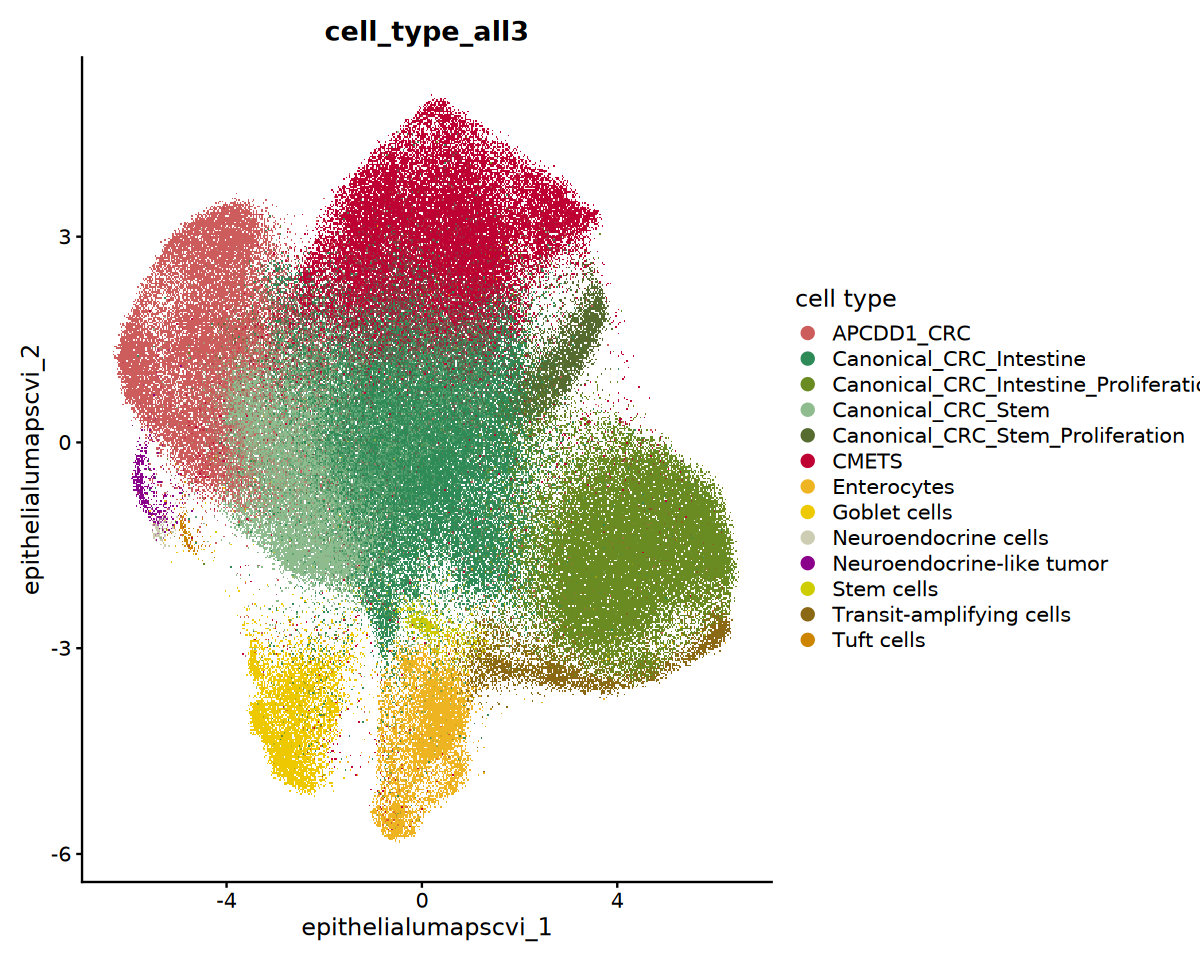

In [14]:
options(repr.plot.width = 10, repr.plot.height = 8)
p1 = DimPlot(tumor_obj, reduction = 'epithelial_umap.scvi', group.by = 'cell_type_all3', label = FALSE) + 
     scale_color_manual(values=epi.cell.color, name='cell type')
p1

In [334]:
pdf(file.path(output_dir, "Umap_mCRC_epithelial_cell_type.pdf"), width=8, height=8)
print(p1)
dev.off()

pdf 
  2

# Normal epithelial

In [20]:
tumor_obj@meta.data <- tumor_obj@meta.data %>% 
                       mutate(Tissue_Type2 = case_when(
                           Tissue_Type == 'metastasis' ~ 'metastasis',
                           Tissue_Type == 'primary' ~ 'primary',
                           orig.ident == 'SP819H1-Mc1' ~ 'CM819C1-normal',
                           orig.ident == 'SP369H1-Mc1' ~ 'SP369H1-normal',
                       )) 

tumor_obj@meta.data <- tumor_obj@meta.data %>%
  mutate(
    Tissue_Type2 = factor(
      Tissue_Type2,
      levels = c("metastasis", "primary", "CM819C1-normal", "SP369H1-normal")
    )
  )

source_umap <- DimPlot(
  tumor_obj,
  group.by = "Tissue_Type2",
  reduction = "epithelial_umap.scvi",
  pt.size = 1.5,
  raster = TRUE,
  cols = c(
    "metastasis" = "grey75",
    "primary" = "palegreen3",
    "CM819C1-normal" = "red",
    "SP369H1-normal" = "blue"
  ),
  order = c("metastasis", "primary", "CM819C1-normal", "SP369H1-normal")
)

source_umap2 <- DimPlot(
  subset(tumor_obj, subset = orig.ident %in% c("SP819H1-Mc1", "SP369H1-Mc1")),
  group.by = "Tissue_Type2",
  reduction = "epithelial_umap.scvi",
  cols = c(
    "CM819C1-normal" = "red",
    "SP369H1-normal" = "blue"
  ),
  pt.size = 2,
  raster = TRUE
)

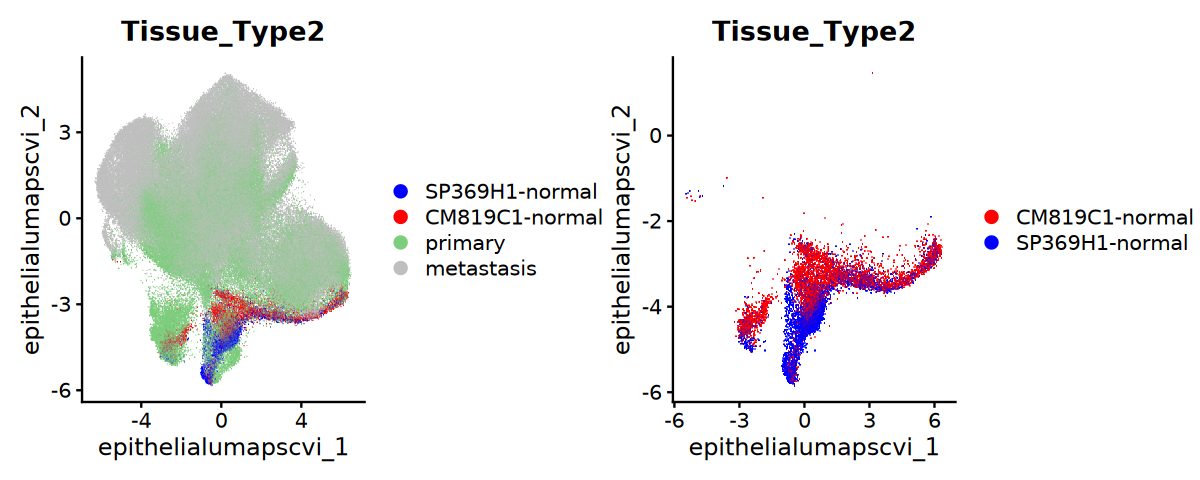

In [16]:
options(repr.plot.width = 10, repr.plot.height = 4)
source_umap + source_umap2

In [159]:
pdf(file.path(output_dir, file.path("Umap_mCRC_sample_source.pdf")), width=10, height=4)
source_umap + source_umap2
dev.off()

pdf 
  2

In [25]:
 unique(epi_df$cell_type_all3)

[1] "APCDD1_CRC"                           
 [2] "Canonical_CRC_Intestine_Proliferation"
 [3] "Canonical_CRC_Intestine"              
 [4] "Canonical_CRC_Stem"                   
 [5] "Canonical_CRC_Stem_Proliferation"     
 [6] "Goblet cells"                         
 [7] "Transit-amplifying cells"             
 [8] "Enterocytes"                          
 [9] "Stem cells"                           
[10] "Tuft cells"

In [39]:
epi_df = tumor_obj@meta.data

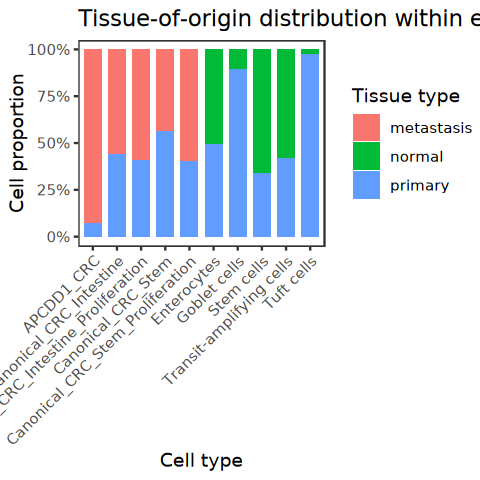

In [38]:
plot2_df <- epi_df %>%
  dplyr::count(cell_type_all3, Tissue_Type) %>%
  group_by(cell_type_all3) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

p2 <- ggplot(plot2_df, aes(x = cell_type_all3, y = prop, fill = Tissue_Type)) +
  geom_col(width = 0.7) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(
    x = "Cell type",
    y = "Cell proportion",
    fill = "Tissue type",
    title = "Tissue-of-origin distribution within each epithelial cell type"
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )

print(p2)

In [32]:
pdf(file.path(output_dir, file.path("Barplot_mCRC_tissue_type_by_epithelial_subtypes.pdf")), width=8, height=8)
print(p2)
dev.off()

pdf 
  2

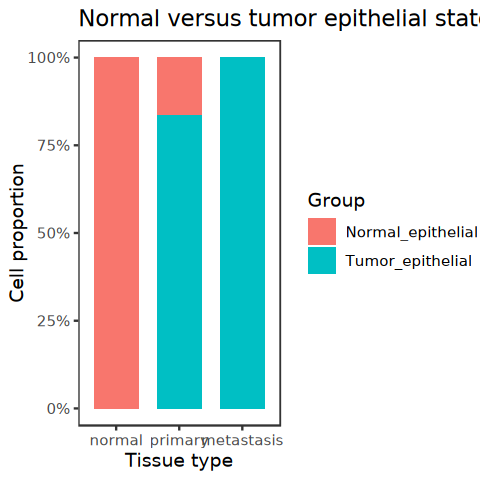

In [40]:
normal_epi_types <- c(
  "Neuroendocrine cells",
  "Goblet cells",
  "Transit-amplifying cells",
  "Enterocytes",
  "Stem cells",
  "Tuft cells"
)

tumor_epi_types <- c(
  "CMETS",  
  "Neuroendocrine-like tumor",   
  "APCDD1_CRC",  
  "Canonical_CRC_Stem",
  "Canonical_CRC_Stem_Proliferation",
  "Canonical_CRC_Intestine_Proliferation", 
  "Canonical_CRC_Intestine"
)

epi_df <- epi_df %>%
  filter(cell_type_all3 %in% c(normal_epi_types, tumor_epi_types)) %>%
  mutate(epi_group = case_when(
    cell_type_all3 %in% normal_epi_types ~ "Normal_epithelial",
    cell_type_all3 %in% tumor_epi_types ~ "Tumor_epithelial"
  ))


plot3_df <- epi_df %>%
  dplyr::count(Tissue_Type, epi_group) %>%
  group_by(Tissue_Type) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

plot3_df$Tissue_Type <- factor(plot3_df$Tissue_Type, level = c('normal', 'primary', 'metastasis'))

p3 <- ggplot(plot3_df, aes(x = Tissue_Type, y = prop, fill = epi_group)) +
  geom_col(width = 0.7) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(
    x = "Tissue type",
    y = "Cell proportion",
    fill = "Group",
    title = "Normal versus tumor epithelial states across tissue types"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank()
  )

options(repr.plot.width = 4, repr.plot.height = 4)
print(p3)

In [41]:
plot3_df

Tissue_Type,epi_group,n,prop
<fct>,<chr>,<int>,<dbl>
metastasis,Normal_epithelial,34,0.0002530233
metastasis,Tumor_epithelial,134341,0.9997469767
normal,Normal_epithelial,8457,1.0000000000
primary,Normal_epithelial,13601,0.1652010203
primary,Tumor_epithelial,68729,0.8347989797


In [42]:
pdf(file.path(output_dir, file.path("Barplot_mCRC_tissue_type_by_epithelial_type.pdf")), width=8, height=8)
print(p3)
dev.off()

pdf 
  2

# Dotplot 

In [89]:
tumor_obj2 <- tumor_obj %>% 
              subset(cell_type_all3 %in% tumor_epi_types)
tumor_obj2

An object of class Seurat 
71822 features across 203071 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: SCT
 8 dimensional reductions calculated: pca, umap.rna, integrated.scvi, mCRCv4_umap.scvi, mCRCv5_umap.scvi, mCRCv6_umap.scvi, epithelial_umap.scvi, epithelial_umap2.scvi

In [136]:
tumor_obj2$cell_type_all3 <- factor(tumor_obj2$cell_type_all3,
                                    level = rev(c(tumor_epi_types)))

In [470]:
saveRDS(tumor_obj2, 
        '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/57_Integrated_normalized_mCRC_snRNA_noDB_v7_epithelial_clean4_tumor_subset_NE.rds')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


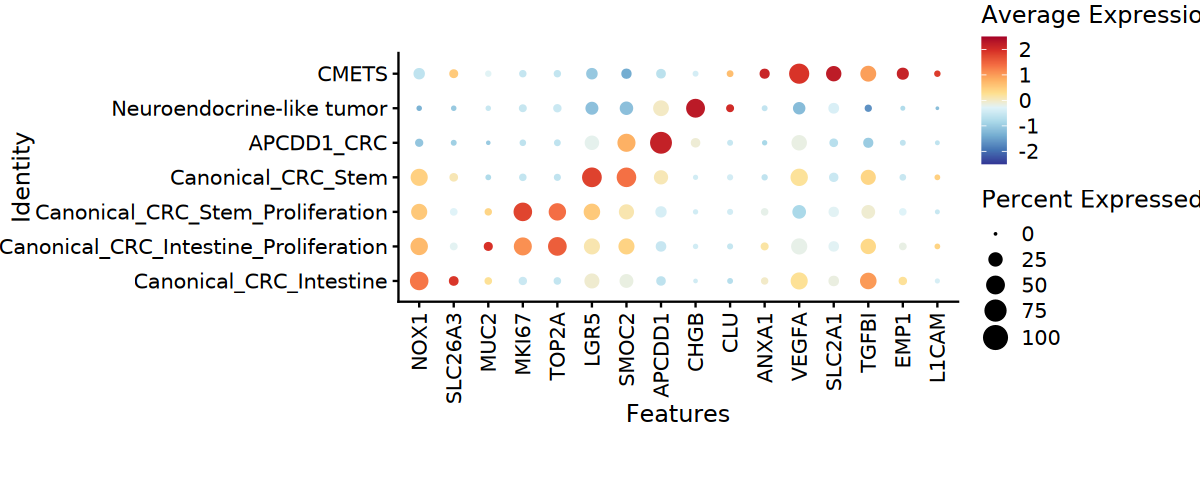

In [138]:
DefaultAssay(tumor_obj2) <- 'SCT'

rdylbu_colors <- rev(colorRampPalette(brewer.pal(10, "RdYlBu"))(10))
color_breaks <- c(-2, -1, 0, 1, 2)

p4 <- DotPlot(tumor_obj2, 
              group.by = 'cell_type_all3', 
              feature = c('NOX1', 'SLC26A3', 'MUC2', 'MKI67', 'TOP2A', 'LGR5', 'SMOC2', 
                          'APCDD1', 'CHGB', 'CLU', 'ANXA1', 'VEGFA', 'SLC2A1', 'TGFBI', 'EMP1', 'L1CAM')) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + #, legend.byrow = FALSE, legend.direction = 'vertical', legend.position = 'bottom') +
      coord_fixed() +
      scale_color_gradientn(colors = rdylbu_colors, 
                            limits = c(-2.5, 2.5),    # Set limits to -2 and 2
                            breaks = color_breaks # Specify the breaks
      ) +         
      scale_size_area(limits = c(0, 100), oob = scales::squish)

options(repr.plot.width = 10, repr.plot.height = 4)
p4

In [139]:
pdf(file.path(output_dir, "Dotplot_mCRC_tumor_cell_type_SCT.pdf"), width=8, height=3)
print(p4)
dev.off()

pdf 
  2

# Geneset AUC score

In [108]:
auc_score_file = '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/mCRC_snRNAseq_epithelial_genesets_auc_score.csv'
auc_score = read.table(auc_score_file, header = TRUE, sep=',', row.name=1)
head(auc_score, 3)

,Absorptive_Intestine,EMT,Endoderm_Development,Injury_Repair,Intestine,Neuroendocrine,Osteoblast,Secretory_Intestine,Squamous,Tumor_ISC_like,⋯,Non_Stem_2_,Stem.TA_,ISC_,Stem.TA_like_,Stem.TA_like.Immature_Goblet_,Stem.TA_like_Proliferative_,Enterocyte_1_,Enterocyte_2_,Goblet.Enterocyte_,Best4_
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HT112C1-T1_AAACCAACAGTTTCTC-1,0.01803343,0.005711444,0.12946223,0.008143939,0.11289443,0.003930799,0.05848932,0.01428525,0.014986957,0.12781264,⋯,0.08357910,0.05916707,0.2896407,0.05540514,0.1079907,0.05509127,0.06678842,0.06594203,0.10426017,0.07427458
HT112C1-T1_AAACCGCGTGCGCAAT-1,0.01627347,0.005485674,0.02340820,0.011049323,0.06959717,0.005747126,0.02180137,0.02820621,0.007882779,0.06378269,⋯,0.09696827,0.19382072,0.1949388,0.18137272,0.1159961,0.13409716,0.10734004,0.13535531,0.08682796,0.09046846
HT112C1-T1_AAACCGCGTTAACGAT-1,0.02231463,0.000935333,0.06160607,0.013064152,0.09168605,0.004334863,0.02961169,0.01034315,0.006169418,0.05169024,⋯,0.05544414,0.05581132,0.3072476,0.05226376,0.1267113,0.07774782,0.08565987,0.10537634,0.07421692,0.06966969


In [109]:
tumor_obj2 <- AddMetaData(tumor_obj2, auc_score)
head(tumor_obj2@meta.data, 3)

,orig.ident,Patient_ID,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,seurat_clusters,S.Score,G2M.Score,⋯,Non_Stem_2_,Stem.TA_,ISC_,Stem.TA_like_,Stem.TA_like.Immature_Goblet_,Stem.TA_like_Proliferative_,Enterocyte_1_,Enterocyte_2_,Goblet.Enterocyte_,Best4_
,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HT112C1-T1_AAACCAACAGTTTCTC-1,HT112C1-T1,HT112C1,7056,3049,0.001275510,3127,1966,2,-0.1390377,-0.07635363,⋯,0.08357910,0.05916707,0.2896407,0.05540514,0.1079907,0.05509127,0.06678842,0.06594203,0.10426017,0.07427458
HT112C1-T1_AAACCGCGTGCGCAAT-1,HT112C1-T1,HT112C1,9842,4221,0.018288966,2752,1849,1,0.4241602,0.30120090,⋯,0.09696827,0.19382072,0.1949388,0.18137272,0.1159961,0.13409716,0.10734004,0.13535531,0.08682796,0.09046846
HT112C1-T1_AAACCGCGTTAACGAT-1,HT112C1-T1,HT112C1,10719,4441,0.001119507,2816,1925,1,0.4051472,0.24396604,⋯,0.05544414,0.05581132,0.3072476,0.05226376,0.1267113,0.07774782,0.08565987,0.10537634,0.07421692,0.06966969


In [143]:
auc_cols <- c(
  "Hallmark_EMT",
  "Hallmark_TGFB",  
  "Hallmark_KRAS_up",  
  "HALLMARK_HYPOXIA",
  "Hallmark_angiogenesis",
  "Neuroendocrine", 
  "Hallmark_WNT",  
  "Stem_",
  "Cycling_TA_",  
  'Epi._Secretory_All_',
  'Epi._Absorptive_All_'  
)

In [144]:
meta <- tumor_obj2@meta.data

meta $cell_type_all3 <- factor(meta$cell_type_all3,
                               level = rev(c(tumor_epi_types)))

median_df <- tumor_obj2@meta.data %>%
  select(cell_type_all3, all_of(auc_cols)) %>%
  group_by(cell_type_all3) %>%
  summarize(
    across(
      everything(),
      ~ median(.x, na.rm = TRUE)
    ),
    .groups = "drop"
  ) %>%
  column_to_rownames("cell_type_all3")

mat <- as.matrix(median_df)

# scale each column: (x – mean(column)) / sd(column)
mat_scaled <- scale(mat, center = TRUE, scale = TRUE)

In [ ]:
mat_clamped <- pmin(pmax(mat_scaled, -1.5), 1.5)
mat_clamped <- mat_clamped[row_order, , drop = FALSE]

col_fun <- colorRamp2(
  c(-1.5, 0, 1.5),
  c("darkgreen", "white", "#be0032")
)

# 4. Draw the heatmap
Heatmap(
  mat_clamped,
  name = "scaled median AUC",
  col    = col_fun, 
  show_row_dend = TRUE,
  show_column_dend = TRUE,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  row_title = "Tumor subcluster",
  column_title = "Gene signature",
  heatmap_legend_param = list(
    title_position = "topcenter",
    legend_direction = "horizontal"
  )
) -> p5

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 4)
p5

In [148]:
pdf(file.path(output_dir, "Heatmap_mCRC_tumor_subtype_AUCell_score.pdf"), width=8, height=4)
print(p5)
dev.off()

pdf 
  2

# CMETS proportion: primary vs. metastasis

In [45]:
sn_sample_info.df <- tumor_obj@meta.data %>% 
                     select(orig.ident, Patient_ID, Tissue_Type, cell_type_all3)
head(sn_sample_info.df,2)

,orig.ident,Patient_ID,Tissue_Type,cell_type_all3
,<chr>,<chr>,<chr>,<chr>
HT112C1-T1_AAACCAACAGTTTCTC-1,HT112C1-T1,HT112C1,metastasis,APCDD1_CRC
HT112C1-T1_AAACCGCGTGCGCAAT-1,HT112C1-T1,HT112C1,metastasis,Canonical_CRC_Intestine_Proliferation


In [49]:
# Step 0: Define sample renaming and merging logic
sample_rename_map <- c(
  'HT413C1-Th1K2A2Nd1_2Bma1_1' = 'HT413C1-Th1K2',
  'HT413C1-Th1K4A2Nd1_2Bma1_1' = 'HT413C1-Th1K4',
  'CM1563C1-S1Y1' = 'CM1563C1-S1',
  'CM1563C1-T1Y1' = 'CM1563C1-T1',
  'CM478C2-T1Y2' = 'CM478C2-T1',
  'CM478C1-T1Y2' = 'CM478C1-T1'
)

merged_sample_map <- c(
  'HT413C1-Th1K2' = 'HT413C1-Th1',
  'HT413C1-Th1K4' = 'HT413C1-Th1'
)

# Step 1: Prepare metadata from tumor_obj and rename samples
metadata <- tumor_obj@meta.data %>%
  select(orig.ident, cell_type_all3, Site_of_Origin, Tissue_Type) %>%
  mutate(
    orig.ident = dplyr::recode(orig.ident, !!!sample_rename_map),
    orig.ident = dplyr::recode(orig.ident, !!!merged_sample_map)
  )

# Step 2: Summarize counts and proportions
tumor_tbl <- metadata %>%
  group_by(orig.ident) %>%
  summarise(
    Organ = dplyr::first(na.omit(Site_of_Origin)),
    tissue_type = dplyr::first(na.omit(Tissue_Type)),  
    
    cell_count = n(),

    CMETS_count = sum(cell_type_all3 == "CMETS", na.rm = TRUE),
    CMETS_proportion = round(100 * CMETS_count / cell_count, 2),

    APCDD1_CRC_count = sum(cell_type_all3 == "APCDD1_CRC", na.rm = TRUE),
    APCDD1_CRC_proportion = round(100 * APCDD1_CRC_count / cell_count, 2),

    NE_count = sum(cell_type_all3 == "Neuroendocrine-like tumor", na.rm = TRUE),
    NE_proportion = round(100 * NE_count / cell_count, 2),

    CIP_count = sum(cell_type_all3 == "Canonical_CRC_Intestine_Proliferation", na.rm = TRUE),
    CIP_proportion = round(100 * CIP_count / cell_count, 2),

    CI_count = sum(cell_type_all3 == "Canonical_CRC_Intestine", na.rm = TRUE),
    CI_proportion = round(100 * CI_count / cell_count, 2),

    CS_count = sum(cell_type_all3 == "Canonical_CRC_Stem", na.rm = TRUE),
    CS_proportion = round(100 * CS_count / cell_count, 2),

    CSP_count = sum(cell_type_all3 == "Canonical_CRC_Stem_Proliferation", na.rm = TRUE),
    CSP_proportion = round(100 * CSP_count / cell_count, 2),

    .groups = "drop"
  )

# Step 3: Process sn_sample_info.df (rename & drop duplicates)
sn_sample_info.df2 <- sn_sample_info.df %>%
  mutate(orig.ident = dplyr::recode(orig.ident, !!!sample_rename_map),
         orig.ident = dplyr::recode(orig.ident, !!!merged_sample_map)) %>%
  distinct(orig.ident, .keep_all = TRUE)

# Step 4: Join with metadata tables
tumor_tbl_merged <- tumor_tbl %>%
  left_join(sn_sample_info.df2, by = "orig.ident") 

In [53]:
tissue_col = c(primary= "#40409C", metastasis = "#BD398D")

# remove C1/C2 suffix for pairing
tumor_tbl_merged$Patient_ID2 <- sub("C[0-9]+$", "", tumor_tbl_merged$Patient_ID)

# keep only primary and metastasis
plot_raw <- tumor_tbl_merged %>%
  filter(Tissue_Type %in% c("primary", "metastasis")) %>%
  mutate(Tissue_Type = factor(Tissue_Type, levels = c("primary", "metastasis")))

# collapse to one value per patient per tissue type for paired analysis
plot_pair <- plot_raw %>%
  group_by(Patient_ID2, Tissue_Type) %>%
  summarise(
    CMETS_proportion = mean(CMETS_proportion, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(Patient_ID2) %>%
  filter(n_distinct(Tissue_Type) == 2) %>%
  ungroup() %>%
  mutate(Tissue_Type = factor(Tissue_Type, levels = c("primary", "metastasis")))

# unpaired t test
stat_unpaired <- plot_raw %>%
  t_test(CMETS_proportion ~ Tissue_Type, paired = FALSE) %>%
  add_xy_position(x = "Tissue_Type")

# paired t test
stat_paired <- plot_pair %>%
  t_test(CMETS_proportion ~ Tissue_Type, paired = TRUE) %>%
  add_xy_position(x = "Tissue_Type")

# place labels at different heights
ymax <- max(plot_raw$CMETS_proportion, na.rm = TRUE)
stat_unpaired$y.position <- ymax * 1.08
stat_paired$y.position   <- ymax * 1.18

stat_unpaired$label <- paste0("unpaired t, p = ", signif(stat_unpaired$p, 3))
stat_paired$label   <- paste0("paired t, p = ", signif(stat_paired$p, 3))

stat_unpaired$y.position <- 52
stat_paired$y.position   <- 57

pbox <- ggplot(plot_raw, aes(x = Tissue_Type, y = CMETS_proportion)) +
  geom_boxplot(aes(fill = Tissue_Type), width = 0.5, outlier.shape = NA, color = "black") +
  geom_line(
    data = plot_pair,
    aes(x = Tissue_Type, y = CMETS_proportion, group = Patient_ID2),
    inherit.aes = FALSE,
    color = "grey70",
    alpha = 0.8
  ) +
  geom_point(
    data = plot_pair,
    aes(x = Tissue_Type, y = CMETS_proportion),
    inherit.aes = FALSE,
    color = "black",
    size = 2
  ) +
  scale_fill_manual(values = tissue_col) +
  scale_y_continuous(limits = c(0, 60)) +
  labs(y = "CMETS proportion") + 
  stat_pvalue_manual(stat_unpaired, label = "label", tip.length = 0.01) +
  stat_pvalue_manual(stat_paired, label = "label", tip.length = 0.01) +
  theme_bw() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


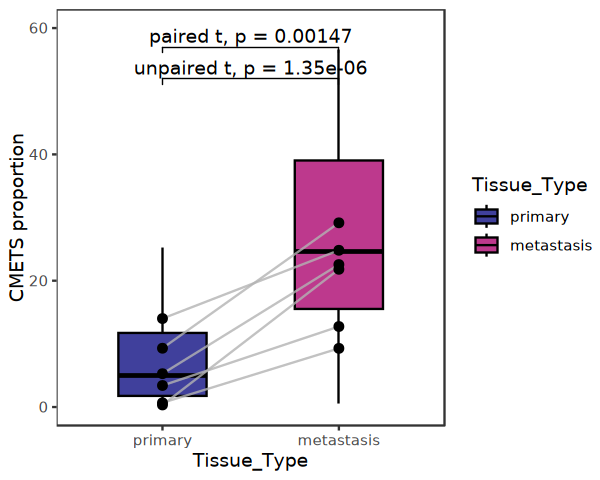

In [54]:
options(repr.plot.width = 5, repr.plot.height = 4)
pbox

In [52]:
pdf(file.path(output_dir, file.path("Barplot_mCRC_CMETS_primary_vs_metastasis.pdf")), width=5, height=4)
print(pbox)
dev.off()

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


pdf 
  2

# KRAS pathway target genes

In [171]:
MAPK_target_genes = c('CCND1', 'CDK4', 'CDK6', 'VEGFA', 'BCL2', 'MCL1') 
MAPK_target_tfs = c('FOS', 'JUN', 'JUNB', 'JUND', 'FOSB', 'ELK1', 'ETV4', 'ETV5', 'MYC')
MAPK_target_sig = c('VEGFA', 'MCL1', 'FOS', 'FOSB')

PI3K_AKT_mTOR_target_genes = c('SLC2A1', 'HK2', 'LDHA', 'RPS6', 'EIF4E', 'BCL2A1', 'XIAP')
PI3K_AKT_mTOR_target_tfs = c('NFKB1', 'NFKB2', 'HIF1A')
PI3K_AKT_mTOR_target_sig = c('SLC2A1', 'HK2', 'LDHA', 'XIAP', 'NFKB1', 'NFKB2', 'HIF1A')

RalGEF_RalA_RalB_target_genes = c('ACTB', 'CDC42', 'EXOC2', 'RALBP1')
RalGEF_RalA_RalB_target_tfs = c('SRF')
RalGEF_RalA_RalB_target_sig = c('ACTB', 'CDC42', 'EXOC2')

Rho_GTPase_target_genes = c('CFL1', 'ACTA2', 'MMP2', 'MMP9')
Rho_GTPase_target_tfs = c('MRTFA', 'MRTFB')
Rho_GTPase_target_sig = c('CFL1', 'MRTFA')

Jak_Stat_target_genes = c('SOCS3', 'BCL2L1', 'IL6')
Jak_Stat_target_tfs = c('STAT3')

Hippo_YAP_TAZ_target_genes = c('CCN1', 'CCN2', 'AXL', 'ITGB2', 'ZEB1', 'RAC1', 'SLUG', 'CDH2', 'CDC42', 'CD274')
Hippo_YAP_TAZ_target_tfs = c('TEAD1', 'TEAD2', 'TEAD3', 'TEAD4', 'CD274')
Hippo_YAP_TAZ_target_sig = c('CCN1', 'CCN2', 'AXL', 'ITGB2', 'ZEB1')

ROS_target_genes = c('NQO1', 'HMOX1', 'GCLC', 'SLC7A11', 'AKR1B10')
ROS_target_tfs = c('NFE2L2', 'BACH1', 'BACH2', 'MAFK')
ROS_target_sig = c('NQO1', 'HMOX1', 'GCLC', 'SLC7A11', 'BACH1', 'BACH2')

KRAS_target_sig = c(MAPK_target_sig, PI3K_AKT_mTOR_target_sig, 
                    RalGEF_RalA_RalB_target_sig, Hippo_YAP_TAZ_target_sig)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


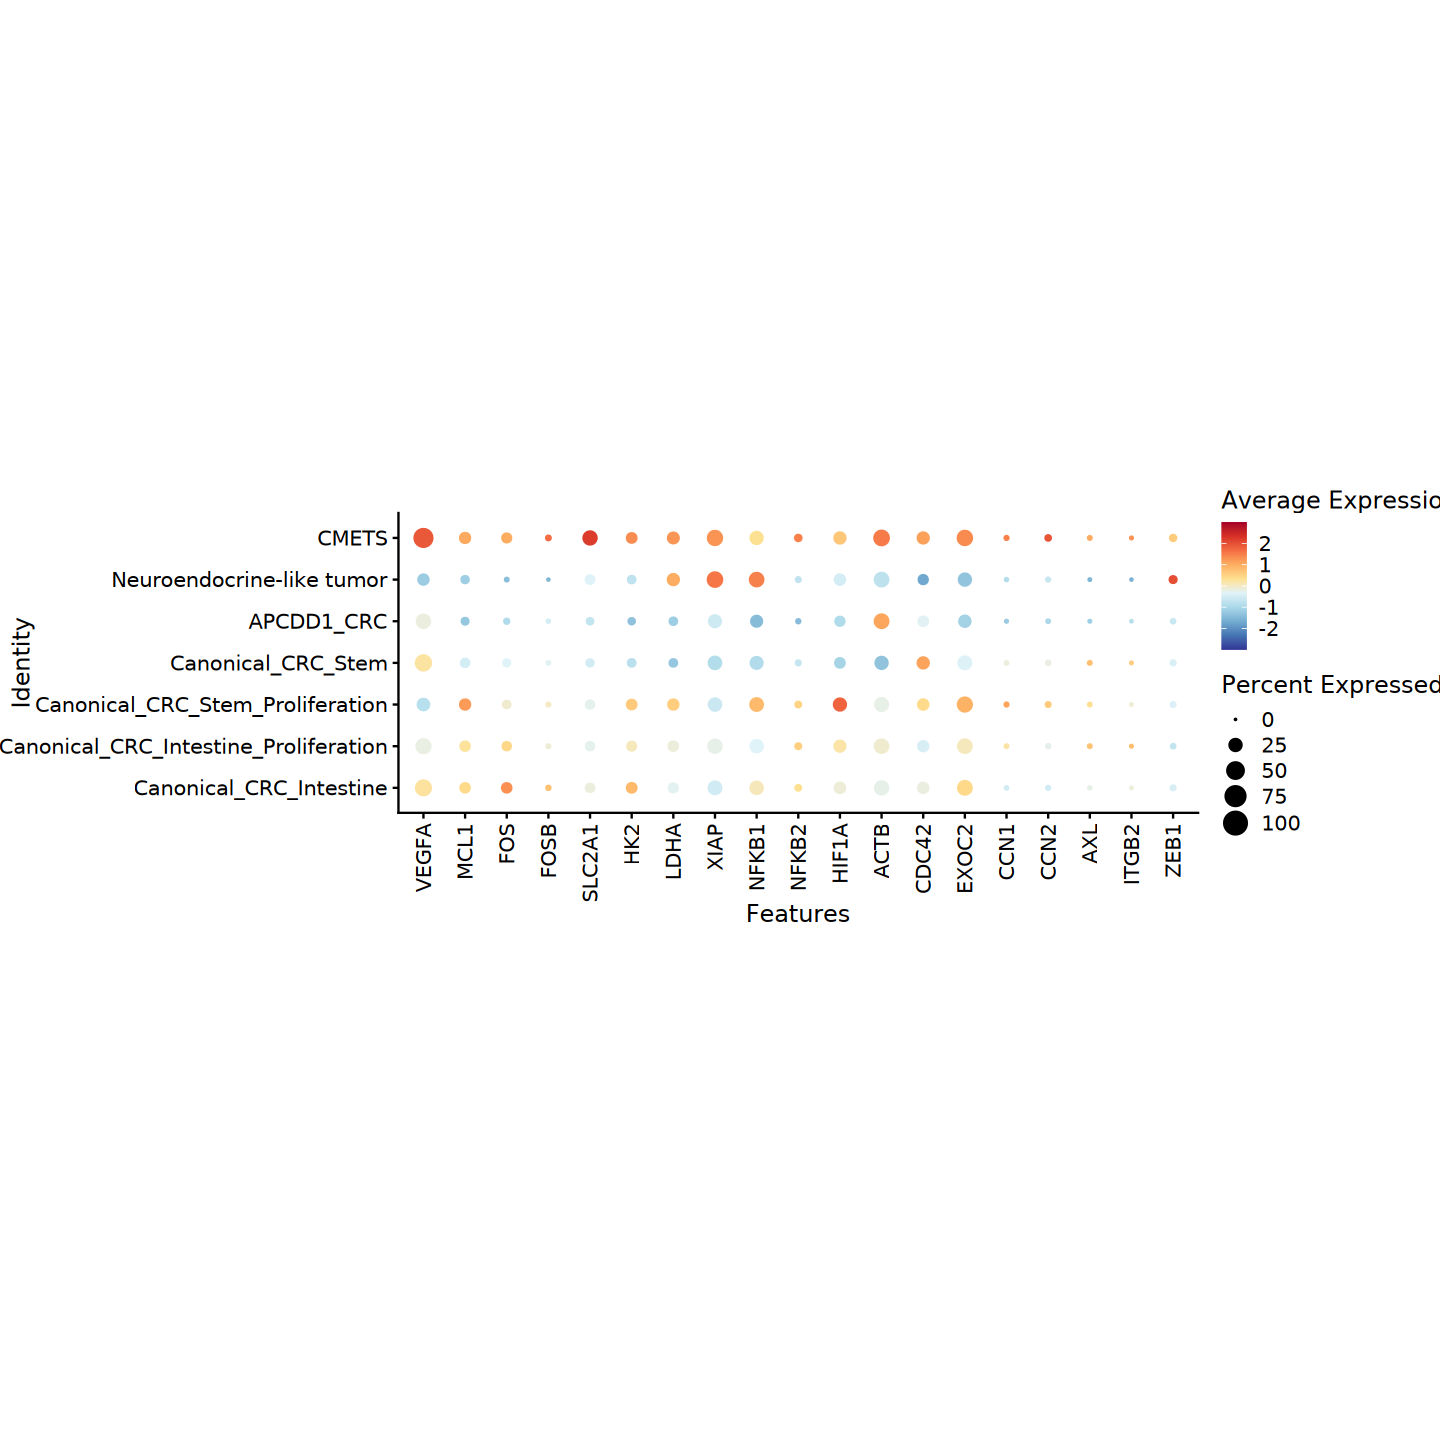

In [174]:
p6 = DotPlot(tumor_obj2, features=KRAS_target_sig , group.by='cell_type_all3') +
theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + 
      coord_fixed() +
      scale_color_gradientn(colors = rdylbu_colors, 
                            limits = c(-3, 3),   
                            breaks = color_breaks) +         
      scale_size_area(limits = c(0, 100), oob = scales::squish)

options(repr.plot.width = 12, repr.plot.height = 12)
p6

In [175]:
pdf(file.path(output_dir, file.path("Dotplot_mCRC_CMETS_KRAS_target.pdf")), width=10, height=5)
print(p6)
dev.off()

pdf 
  2

# AP1 target

In [179]:
NCC_AP1_sorted_genes = c('SLC2A1', 'LDHA', 'PDK1', 'HSPB1', 'HSPA1B', 
                         'LAMC2', 'LAMB3', 'LAMA3', 'ITGA3', 'LTBP1', 'SDC4',
                         'TGFA', 'JAG1', 'MAPKAPK2', 'BIRC2', 
                         'PLAUR', 'IL13RA1', 'CD55', 
                         'MCL1', 'PPP1R13L', 'EMP1'
                        )

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


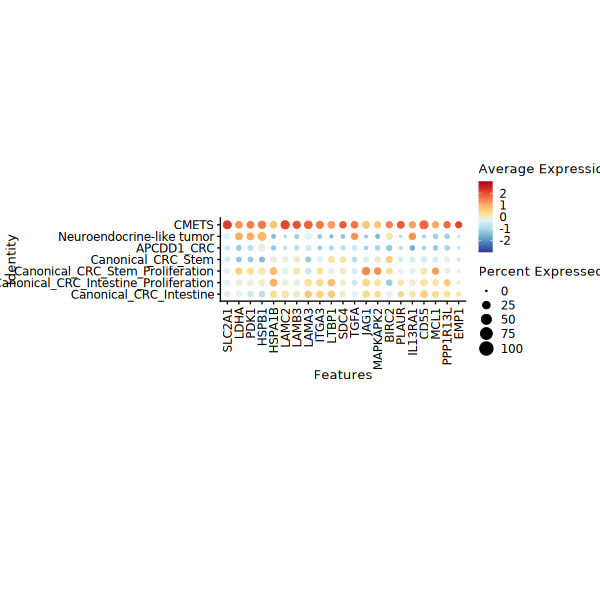

In [180]:
p7 = DotPlot(tumor_obj2, features=NCC_AP1_sorted_genes , group.by='cell_type_all3') +
theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + 
      coord_fixed() +
      scale_color_gradientn(colors = rdylbu_colors, 
                            limits = c(-3, 3),   
                            breaks = color_breaks) +         
      scale_size_area(limits = c(0, 100), oob = scales::squish)

set_size(6,6)
p7

In [181]:
pdf(file.path(output_dir, file.path("Dotplot_mCRC_CMETS_AP1_target.pdf")), width=10, height=5)
print(p7)
dev.off()

pdf 
  2

# KRAS and CMETS abundance

In [212]:
tumor_tbl <- tumor_tbl %>%
  mutate(
    Case_ID = str_extract(orig.ident, ".*C(?=\\d)")
  ) %>% 
  filter(!is.na(Case_ID))

In [300]:
clinical_info_selected <- read.csv('/diskmnt/Projects/MetNet_analysis/Colorectal/mCRC_Manuscript_Script/H_Organ_specific_adaption/Case_mutation_status_update.csv')
tumor_mut_tbl <- tumor_tbl %>% 
                  left_join(clinical_info_selected, by = c("Case_ID" = "Case_ID")) %>% 
                  filter(!(Case_ID %in% c('HT413C', 'CM329C', 'CM655C'))) %>% 
                  filter(Organ %in% c('colon', 'liver', 'lung', 'rectum')) %>%  
                  mutate(APC_mut = case_when(
                         APC == 'wt' ~ 'No',
                         APC == 'mut' ~ 'Yes'),
                         KRAS_mut = case_when(
                         KRAS == 'wt' ~ 'No',
                         KRAS == 'mut' ~ 'Yes'),
                         TP53_mut = case_when(
                         TP53 == 'wt' ~ 'No',
                         TP53 == 'mut' ~ 'Yes')
                  )
primary_mut_tbl <- tumor_mut_tbl %>% filter(tissue_type == 'primary')
met_mut_tbl <- tumor_mut_tbl %>% filter(tissue_type == 'metastasis')
liver_mut_tbl <- tumor_mut_tbl %>% filter(Organ == 'liver')
head(tumor_mut_tbl, 3)

orig.ident,Organ,tissue_type,cell_count,CMETS_count,CMETS_proportion,APCDD1_CRC_count,APCDD1_CRC_proportion,NE_count,NE_proportion,⋯,KRAS,TP53,APC,ROS1,FU_days,Tx_in_6mo,Survival,APC_mut,KRAS_mut,TP53_mut
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
CM1563C1-S1,colon,primary,2664,248,9.31,6,0.23,0,0.00,⋯,mut,wt,wt,wt,1227,Yes,alive,No,Yes,No
CM1563C1-T1,liver,metastasis,144,42,29.17,24,16.67,3,2.08,⋯,mut,wt,wt,wt,1227,Yes,alive,No,Yes,No
CM268C1-S1,colon,primary,1205,4,0.33,1,0.08,0,0.00,⋯,wt,mut,mut,wt,30,No,dead,Yes,No,Yes


In [301]:
write.csv(tumor_mut_tbl, 
          file.path(output_dir, 'tumor_mut_tbl_NE_included.csv'))

In [302]:
tumor_KRAS_tbl_filter = tumor_mut_tbl %>% filter(!is.na(KRAS_mut) & cell_count > 50)

tumor_KRAS_tbl_filter %>%
  group_by(KRAS_mut) %>%
  summarise(
    mean_prop = mean(CMETS_proportion, na.rm = TRUE),
    median_prop = median(CMETS_proportion, na.rm = TRUE),
    n = n()
  )

wilcox.test(
  CMETS_proportion ~ KRAS_mut,
  data = tumor_KRAS_tbl_filter
)

p_kras <- ggplot(tumor_KRAS_tbl_filter, 
       aes(x = KRAS_mut, y = CMETS_proportion, fill = KRAS_mut)) +
       geom_boxplot(alpha = 0.6) +
       geom_point(alpha = 1) +
       labs(
           x = "KRAS mutation",
           y = "CMETS"
       ) +
       theme_mydefault() +
       coord_cartesian(ylim = c(0, 50)) +
       stat_compare_means(method = "wilcox.test", 
                          label = "p.format",
                          label.y = 50
                         ) 

KRAS_mut,mean_prop,median_prop,n
<chr>,<dbl>,<dbl>,<int>
No,14.81704,14.01,27
Yes,27.15692,24.29,13



	Wilcoxon rank sum exact test

data:  CMETS_proportion by KRAS_mut
W = 99, p-value = 0.02682
alternative hypothesis: true location shift is not equal to 0


In [303]:
tumor_APC_tbl_filter = tumor_mut_tbl %>% filter(!is.na(APC_mut) & cell_count > 50)

tumor_APC_tbl_filter %>%
  group_by(APC_mut) %>%
  summarise(
    mean_prop = mean(CMETS_proportion, na.rm = TRUE),
    median_prop = median(CMETS_proportion, na.rm = TRUE),
    n = n()
  )

wilcox.test(
  CMETS_proportion ~ APC_mut,
  data = tumor_APC_tbl_filter
)

p_apc <- ggplot(tumor_APC_tbl_filter, 
       aes(x = APC_mut, y = CMETS_proportion, fill = APC_mut)) +
       geom_boxplot(alpha = 0.6) +
       geom_point(alpha = 1) +
       labs(
           x = "APC mutation",
           y = "CMETS proportion"
       ) +
       theme_mydefault() +
       coord_cartesian(ylim = c(0, 50)) +
       stat_compare_means(method = "wilcox.test", 
                          label = "p.format",
                          label.y = 50
                         ) 


APC_mut,mean_prop,median_prop,n
<chr>,<dbl>,<dbl>,<int>
No,16.22556,16.45,9
Yes,19.58290,16.94,31



	Wilcoxon rank sum exact test

data:  CMETS_proportion by APC_mut
W = 131, p-value = 0.7991
alternative hypothesis: true location shift is not equal to 0


In [304]:
tumor_TP53_tbl_filter = tumor_mut_tbl %>% filter(!is.na(TP53_mut) & cell_count > 50)

tumor_TP53_tbl_filter %>%
  group_by(TP53_mut) %>%
  summarise(
    mean_prop = mean(CMETS_proportion, na.rm = TRUE),
    median_prop = median(CMETS_proportion, na.rm = TRUE),
    n = n()
  )

wilcox.test(
  CMETS_proportion ~ TP53_mut,
  data = tumor_TP53_tbl_filter
)

p_tp53 <- ggplot(tumor_TP53_tbl_filter, 
       aes(x = TP53_mut, y = CMETS_proportion, fill = TP53_mut)) +
       geom_boxplot(alpha = 0.6) +
       geom_point(alpha = 1) +
       labs(
           x = "TP53 mutation",
           y = "CMETS proportion"
       ) +
       theme_mydefault() +
       coord_cartesian(ylim = c(0, 50)) +
       stat_compare_means(method = "wilcox.test", 
                          label = "p.format",
                          label.y = 50
                         ) 


TP53_mut,mean_prop,median_prop,n
<chr>,<dbl>,<dbl>,<int>
No,17.76615,9.29,13
Yes,19.33852,17.94,27



	Wilcoxon rank sum exact test

data:  CMETS_proportion by TP53_mut
W = 144, p-value = 0.3755
alternative hypothesis: true location shift is not equal to 0


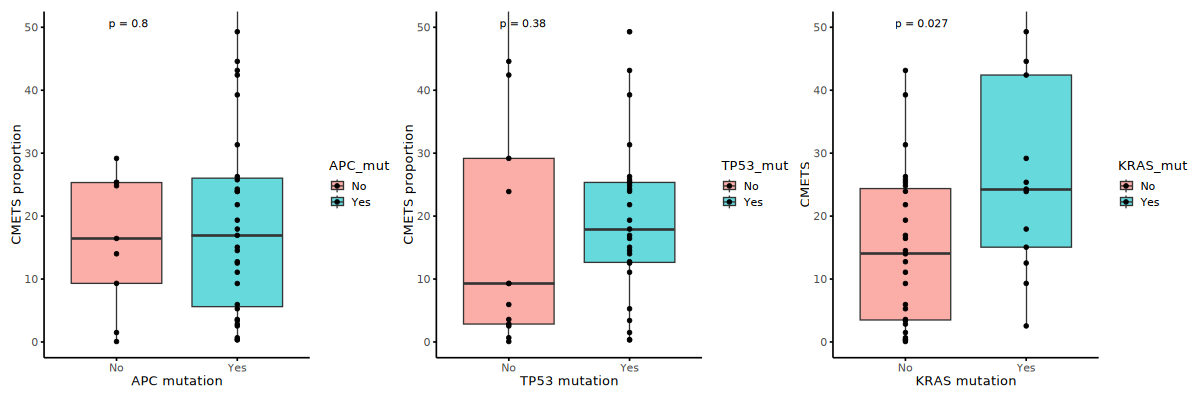

In [305]:
set_size(12, 4)
(p_apc + p_tp53 + p_kras) + plot_layout(ncol = 3)


In [306]:
pdf(file=file.path(output_dir, 'mCRC_snRNA_TP53_APC_KRAS_MUT_ALL_non_canonical_barplot.pdf'), width=10, height=5) 
(p_apc + p_tp53 + p_kras) + plot_layout(ncol = 3)
dev.off()

pdf 
  2

# KRAS & Organ stepwise

In [307]:
tumor_KRAS_tbl_filtered <- tumor_mut_tbl  %>% 
                           filter(Organ %in% c('colon', 'liver', 'lung', 'rectum')) %>% 
                           filter(!is.na(KRAS_mut) & cell_count > 50) %>% 
                           filter(!(Case_ID %in% c('HT413C', 'CM655C', 'CM329C'))) %>% 
                           mutate(Organ = case_when(
                                          Organ %in% c('colon', 'rectum') ~ 'colorectum',
                                          Organ == 'liver' ~ 'liver',
                                          Organ == 'lung' ~ 'lung'),
                                  Organ_KRAS_mut = paste0(Organ, '_', KRAS_mut)) %>% 
                           select(Case_ID, CMETS_proportion, Organ, KRAS_mut, Organ_KRAS_mut)
tumor_KRAS_tbl_filtered$Organ_KRAS_mut <- factor(tumor_KRAS_tbl_filtered$Organ_KRAS_mut, 
                                                 level = c('colorectum_No', 'colorectum_Yes',
                                                           'liver_No', 'liver_Yes',
                                                           'lung_No', 'lung_Yes'
                                                          ))

In [308]:
kruskal.test(CMETS_proportion ~ Organ_KRAS_mut, 
             data = tumor_KRAS_tbl_filtered)  


	Kruskal-Wallis rank sum test

data:  CMETS_proportion by Organ_KRAS_mut
Kruskal-Wallis chi-squared = 22.333, df = 5, p-value = 0.0004526


In [309]:
organ_col <- c(colorectum = '#C2B280', liver = 'brown', lung = 'steelblue1')

ggplot(tumor_KRAS_tbl_filtered, 
       aes(x = Organ, y = CMETS_proportion, fill = KRAS_mut)) +
  geom_boxplot(alpha = 0.6, position = position_dodge(width = 0.8)) +
  geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8), 
             alpha = 1, size = 3) +
  labs(
    x = "Organ",
    y = "CMETS proportion",
    fill = "KRAS mutation"
  ) +
  theme_mydefault() -> p_merged

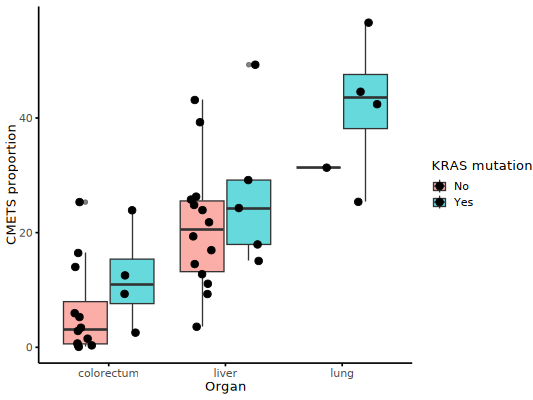

In [310]:
options(repr.plot.width = 8, repr.plot.height = 6)
p_merged

In [311]:
pdf(file=file.path(output_dir, 'mCRC_snRNA_KRAS_Organ_boxplot.pdf'), width=8, height=5) 
p_merged
dev.off()

pdf 
  2

# Linear regrsssion

In [319]:
# Prep: keep needed cols, drop NAs, make factors + set sensible baselines
tumor_KRAS_tbl <- tumor_mut_tbl %>% 
                  mutate(KRAS_ROS1 = case_when(
                         KRAS_mut == 'Yes' & ROS1 == 'mut' ~ 'Both_mut',
                         KRAS_mut == 'Yes' ~ 'KRAS_only',
                         ROS1 == 'mut' ~ 'ROS1_only',
                         KRAS_mut == 'No' & ROS1 == 'wt' ~ 'Both_wt'
                  ))

df <- tumor_KRAS_tbl %>%
  filter(cell_count > 50) %>%
  filter(!(Case_ID %in% c('HT413C', 'CM655C', 'CM329C'))) %>% 
  select(Case_ID, cell_count, CMETS_proportion, Sex, Race, Organ, KRAS_ROS1, Tx_in_6mo) %>%
  mutate(Organ = case_when(Organ %in% c('colon', 'rectum') ~ 'colorectum',
                           TRUE ~ Organ)) %>% 
  mutate(KRAS_ROS1 = case_when(#Case_ID == 'CM392C' ~ 'Either_mut',
                               KRAS_ROS1 == 'Both_wt' ~ 'Both_wt',
                               TRUE ~ 'Either_mut'
                              )) %>% 
  filter(complete.cases(.)) %>%
  filter(Organ %in% c('colorectum', 'liver', 'lung')) %>% 
  mutate(
    Sex = as.factor(Sex),
    Race = as.factor(Race),  
    Organ    = as.factor(Organ),
    KRAS_ROS1 = as.factor(KRAS_ROS1),
    Tx_in_6mo = as.factor(Tx_in_6mo),
    #MSI = as.factor(MSI)  
  )

# Optional: set reference levels if present
if ("colorectum" %in% levels(df$Organ)) df$Organ <- relevel(df$Organ, "colorectum")
if ("No" %in% levels(df$Tx_in_6mo))     df$Tx_in_6mo <- relevel(df$Tx_in_6mo, "No")
if ("M" %in% levels(df$Sex))            df$Sex <- relevel(df$Sex, "M")
if ("White" %in% levels(df$Race))       df$Race <- relevel(df$Race, "White")
df$KRAS_ROS1 <- factor(df$KRAS_ROS1, level = c('Both_wt', 'Either_mut'))


Call:
lm(formula = CMETS_proportion ~ Organ + KRAS_ROS1 + Tx_in_6mo + 
    Sex + Race, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.6178  -4.9004   0.1068   5.2998  18.0256 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -1.105      3.837  -0.288    0.775    
Organliver             14.647      3.267   4.483 7.95e-05 ***
Organlung              23.507      5.257   4.472 8.23e-05 ***
KRAS_ROS1Either_mut    14.708      3.091   4.758 3.53e-05 ***
Tx_in_6moYes            5.307      3.714   1.429    0.162    
SexF                   -2.293      3.140  -0.730    0.470    
RaceAfrican American    3.514      3.769   0.932    0.358    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.161 on 34 degrees of freedom
Multiple R-squared:  0.703,	Adjusted R-squared:  0.6506 
F-statistic: 13.41 on 6 and 34 DF,  p-value: 9.634e-08


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Organ,2455.57769,2,14.6306241,2.604952e-05
KRAS_ROS1,1899.81356,1,22.6386306,3.529842e-05
Tx_in_6mo,171.40254,1,2.0424735,1.620848e-01
Sex,44.76155,1,0.5333893,4.701882e-01
Race,72.92307,1,0.8689686,3.578137e-01
Residuals,2853.24948,34,NA,NA


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.104927,3.837441,-0.2879333,7.751457e-01,-8.903545,6.693691
Organliver,14.647422,3.267285,4.4830555,7.954020e-05,8.007499,21.287345
Organlung,23.507146,5.257006,4.4715844,8.226814e-05,12.823625,34.190668
KRAS_ROS1Either_mut,14.708025,3.091215,4.7580070,3.529842e-05,8.425919,20.990131
Tx_in_6moYes,5.307323,3.713619,1.4291513,1.620848e-01,-2.239658,12.854304
SexF,-2.293434,3.140249,-0.7303351,4.701882e-01,-8.675188,4.088320
RaceAfrican American,3.513648,3.769261,0.9321849,3.578137e-01,-4.146412,11.173708


,GVIF,Df,GVIF^(1/(2*Df))
Organ,1.410791,2,1.089847
KRAS_ROS1,1.160888,1,1.077445
Tx_in_6mo,1.154363,1,1.074413
Sex,1.186544,1,1.089286
Race,1.189215,1,1.090511


 Organ      emmean   SE df lower.CL upper.CL
 colorectum   9.51 2.98 34     3.47     15.6
 liver       24.16 2.71 34    18.65     29.7
 lung        33.02 4.53 34    23.82     42.2

Results are averaged over the levels of: KRAS_ROS1, Tx_in_6mo, Sex, Race 
Confidence level used: 0.95 

 contrast           estimate   SE df t.ratio p.value
 colorectum - liver   -14.65 3.27 34  -4.483  0.0002
 colorectum - lung    -23.51 5.26 34  -4.472  0.0002
 liver - lung          -8.86 5.06 34  -1.751  0.2014

Results are averaged over the levels of: KRAS_ROS1, Tx_in_6mo, Sex, Race 
P value adjustment: tukey method for comparing a family of 3 estimates 

 KRAS_ROS1  emmean   SE df lower.CL upper.CL
 Both_wt      14.9 2.87 34     9.04     20.7
 Either_mut   29.6 2.60 34    24.29     34.9

Results are averaged over the levels of: Organ, Tx_in_6mo, Sex, Race 
Confidence level used: 0.95 

 Tx_in_6mo emmean   SE df lower.CL upper.CL
 No          19.6 3.63 34     12.2     26.9
 Yes         24.9 2.00 34     20.8     29.0

Results are averaged over the levels of: Organ, KRAS_ROS1, Sex, Race 
Confidence level used: 0.95 

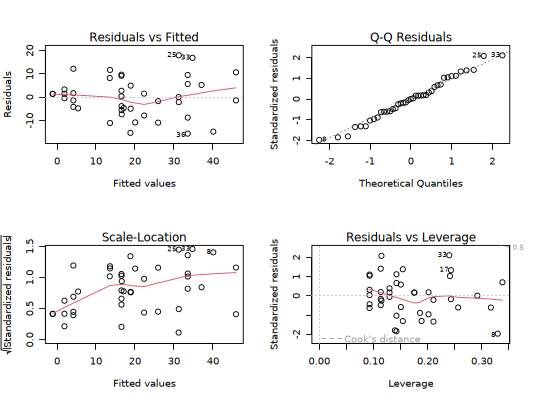

In [323]:
# Fit the multivariable linear regression
fit <- lm(CMETS_proportion ~ Organ + KRAS_ROS1 + Tx_in_6mo + Sex + Race, data = df)

# Main results
summary(fit)                 # coefficients, SEs, p-values, R^2
car::Anova(fit, type = 2)    # Type II tests (robust to unbalanced designs)
broom::tidy(fit, conf.int = TRUE)

# Multicollinearity check
car::vif(fit)

# Estimated marginal means (main-effect comparisons)
emmeans(fit, ~ Organ)
pairs(emmeans(fit, ~ Organ), adjust = "tukey")

emmeans(fit, ~ KRAS_ROS1)
emmeans(fit, ~ Tx_in_6mo)

# Quick diagnostics
par(mfrow = c(2,2)); plot(fit); par(mfrow=c(1,1))


In [331]:
coef_df

term,estimate,std.error,statistic,p.value,conf.low,conf.high,pretty
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
Organliver,14.647422,3.267285,4.4830555,7.954020e-05,8.007499,21.28734,Organ: liver
Organlung,23.507146,5.257006,4.4715844,8.226814e-05,12.823625,34.19067,Organ: lung
KRAS_ROS1Either_mut,14.708025,3.091215,4.7580070,3.529842e-05,8.425919,20.99013,KRAS/ROS1 mut: Either_mut
Tx_in_6moYes,5.307323,3.713619,1.4291513,1.620848e-01,-2.239658,12.85430,NA
SexF,-2.293434,3.140249,-0.7303351,4.701882e-01,-8.675188,4.08832,Sex: F
RaceAfrican American,3.513648,3.769261,0.9321849,3.578137e-01,-4.146412,11.17371,Race: African American


In [332]:
coef_df <- tidy(fit, conf.int = TRUE) %>%
  filter(term != "(Intercept)") %>%
  mutate(pretty = term |>
           gsub("^Organ",    "Organ: ",    x = _) |>
           gsub("^KRAS_ROS1", "KRAS/ROS1 mut: ", x = _) |>
           gsub("^Tx_in_6mo","Tx in 6 mo: ", x = _) |>
           gsub("^Sex",      "Sex: ",      x = _) |>
           gsub("^Race",     "Race: ",     x = _))

coef_df$pretty <- factor(coef_df$pretty, level = c('Sex: F', 'Race: African American', 'Tx in 6 mo: Yes',
                                                   'KRAS/ROS1 mut: Either_mut', 'Organ: liver', 'Organ: lung'))

ggplot(coef_df, aes(x = estimate, y = pretty)) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  geom_point(size = 2.6) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.15) +
  #scale_x_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(x = "Adjusted change in CMETS proportion", y = NULL) +
  theme_classic(base_size = 14) -> p_forest



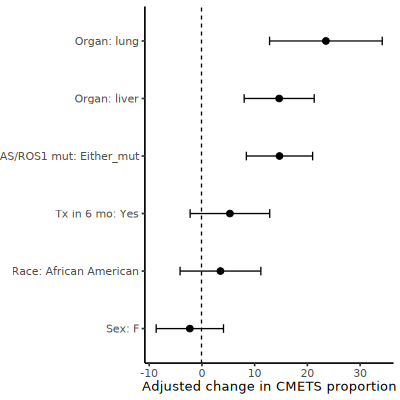

In [333]:
set_size(4,4)
p_forest

In [341]:
pdf(file=file.path(output_dir, 'mCRC_snRNA_KRAS_ROS1_Organ_forest.pdf'), width=6, height=5) 
p_forest
dev.off()

write.csv(coef_df, file.path(output_dir, 'mCRC_snRNA_linear_regression_forest_plot_table.csv'))

pdf 
  2

# snRNA-seq CMETS survival

In [345]:
tumor_tbl_survival <- tumor_mut_tbl %>% 
                      mutate(Vital_status = case_when(Survival == 'dead' ~ 1,
                                                      Survival == 'alive' ~ 0))

In [346]:
colnames(tumor_tbl_survival)

[1] "orig.ident"            "Organ"                 "tissue_type"          
 [4] "cell_count"            "CMETS_count"           "CMETS_proportion"     
 [7] "APCDD1_CRC_count"      "APCDD1_CRC_proportion" "NE_count"             
[10] "NE_proportion"         "CIP_count"             "CIP_proportion"       
[13] "CI_count"              "CI_proportion"         "CS_count"             
[16] "CS_proportion"         "CSP_count"             "CSP_proportion"       
[19] "Case_ID"               "Sex"                   "Race"                 
[22] "KRAS"                  "TP53"                  "APC"                  
[25] "ROS1"                  "FU_days"               "Tx_in_6mo"            
[28] "Survival"              "APC_mut"               "KRAS_mut"             
[31] "TP53_mut"              "Vital_status"

In [350]:
prepare_survival_data <- function(data, tissue_type_col = "tissue_type", tissue_type_value = "metastasis", 
                                  time_col_days = "FU_days", 
                                  proportions_cols = list("CMETS_proportion", 
                                                          "NE_proportion",
                                                          "APCDD1_CRC_proportion", 
                                                          "CS_proportion",
                                                          "CIP_proportion", 
                                                          "CSP_proportion", 
                                                          "CI_proportion")) {
  
  # Filter the data for the specified tissue type
  filtered_data <- data %>% filter(!!sym(tissue_type_col) == tissue_type_value)
  
  # Calculate the median values for each specified tumor proportion column
  medians <- lapply(proportions_cols, function(col) {
    median(filtered_data[[col]], na.rm = TRUE)
  })
  names(medians) <- proportions_cols
  
  # Create grouping variables based on the median values
  for (col in proportions_cols) {
    group_col_name <- paste0(gsub("_tumor_proportion", "", col), "_tumor_group")
    print(paste(col, 'median:', medians[[col]]))  
    filtered_data[[group_col_name]] <- ifelse(filtered_data[[col]] <= medians[[col]], "Low", "High")
  }
  
  # Convert time from days to months
  time_col_months <- gsub("_days", "_months", time_col_days)
  time_col_years <- gsub("_days", "_years", time_col_days)  
  filtered_data[[time_col_months]] <- filtered_data[[time_col_days]] / 30
  filtered_data[[time_col_years]] <- filtered_data[[time_col_days]] / 365.25  
  
  # Filter out rows with NA in the time column
  result_data <- filtered_data %>% filter(!is.na(filtered_data[[time_col_days]]))
  
  return(result_data)
}

In [405]:
liver_sample_tbl <- prepare_survival_data(tumor_tbl_survival,
                                          tissue_type_col = "Organ", 
                                          tissue_type_value = "liver",
                                          time_col_days = "FU_days"
                                         )

liver_sample_tbl2 <- liver_sample_tbl %>% 
                     #filter(cell_count > 10) %>%  
                     filter(Case_ID!= 'CM268C') %>% # CM268C was only followed for 1 month
                     mutate(CMETS_low_stem = if_else(CMETS_proportion_tumor_group == 'High' & 
                                                     CS_proportion_tumor_group == 'Low', 
                                                     'High_CMETS_Low_stem',
                                                     'Others'))

table(liver_sample_tbl2$Vital_status)

[1] "CMETS_proportion median: 21.81"
[1] "NE_proportion median: 0"
[1] "APCDD1_CRC_proportion median: 4.02"
[1] "CS_proportion median: 10.38"
[1] "CIP_proportion median: 15.37"
[1] "CSP_proportion median: 2.16"
[1] "CI_proportion median: 31.94"



 0  1 
13  7 

In [406]:
fit_cmets = coxph(Surv(FU_months, Vital_status) ~ CMETS_proportion,
      data = liver_sample_tbl2)
summary(fit_cmets)
exp(cbind(HR = coef(fit_cmets), confint(fit_cmets)))

Call:
coxph(formula = Surv(FU_months, Vital_status) ~ CMETS_proportion, 
    data = liver_sample_tbl2)

  n= 20, number of events= 7 

                    coef exp(coef) se(coef)     z Pr(>|z|)
CMETS_proportion 0.04426   1.04526  0.03324 1.331    0.183

                 exp(coef) exp(-coef) lower .95 upper .95
CMETS_proportion     1.045     0.9567    0.9793     1.116

Concordance= 0.667  (se = 0.107 )
Likelihood ratio test= 1.67  on 1 df,   p=0.2
Wald test            = 1.77  on 1 df,   p=0.2
Score (logrank) test = 1.88  on 1 df,   p=0.2


,HR,2.5 %,97.5 %
CMETS_proportion,1.045255,0.9793239,1.115625


In [364]:
fit_stem = coxph(Surv(FU_months, Vital_status) ~ CS_proportion,
      data = liver_sample_tbl2)
summary(fit_stem)
exp(cbind(HR = coef(fit_stem), confint(fit_stem)))

Call:
coxph(formula = Surv(FU_months, Vital_status) ~ CS_proportion, 
    data = liver_sample_tbl2)

  n= 20, number of events= 7 

                 coef exp(coef) se(coef)      z Pr(>|z|)  
CS_proportion -0.2034    0.8159   0.1094 -1.859    0.063 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

              exp(coef) exp(-coef) lower .95 upper .95
CS_proportion    0.8159      1.226    0.6585     1.011

Concordance= 0.815  (se = 0.063 )
Likelihood ratio test= 8.72  on 1 df,   p=0.003
Wald test            = 3.46  on 1 df,   p=0.06
Score (logrank) test = 5.71  on 1 df,   p=0.02


,HR,2.5 %,97.5 %
CS_proportion,0.8159398,0.6584649,1.011076


In [381]:
fit_cmets_stem = coxph(Surv(FU_months, Vital_status) ~ CMETS_proportion + CS_proportion, 
                       data = liver_sample_tbl2)
summary(fit_cmets_stem )
exp(cbind(HR = coef(fit_cmets_stem ), confint(fit_cmets_stem )))

Call:
coxph(formula = Surv(FU_months, Vital_status) ~ CMETS_proportion + 
    CS_proportion, data = liver_sample_tbl2)

  n= 20, number of events= 7 

                     coef exp(coef) se(coef)      z Pr(>|z|)  
CMETS_proportion  0.01242   1.01250  0.03332  0.373   0.7093  
CS_proportion    -0.18808   0.82855  0.11056 -1.701   0.0889 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 exp(coef) exp(-coef) lower .95 upper .95
CMETS_proportion    1.0125     0.9877    0.9485     1.081
CS_proportion       0.8286     1.2069    0.6671     1.029

Concordance= 0.864  (se = 0.065 )
Likelihood ratio test= 8.86  on 2 df,   p=0.01
Wald test            = 4.07  on 2 df,   p=0.1
Score (logrank) test = 6.5  on 2 df,   p=0.04


,HR,2.5 %,97.5 %
CMETS_proportion,1.012498,0.9484941,1.080822
CS_proportion,0.828552,0.6671271,1.029037


In [399]:
liver_sample_tbl2$CMETS_low_stem <- factor(liver_sample_tbl2$CMETS_low_stem,
                                           level = c('Others', 'High_CMETS_Low_stem')
                                          )

fit_cmets = coxph(Surv(FU_months, Vital_status) ~ CMETS_low_stem,
      data = liver_sample_tbl2)
summary(fit_cmets)
exp(cbind(HR = coef(fit_cmets), confint(fit_cmets)))

Call:
coxph(formula = Surv(FU_months, Vital_status) ~ CMETS_low_stem, 
    data = liver_sample_tbl2)

  n= 20, number of events= 7 

                                    coef exp(coef) se(coef)     z Pr(>|z|)  
CMETS_low_stemHigh_CMETS_Low_stem 1.4176    4.1272   0.7829 1.811   0.0702 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                                  exp(coef) exp(-coef) lower .95 upper .95
CMETS_low_stemHigh_CMETS_Low_stem     4.127     0.2423    0.8896     19.15

Concordance= 0.71  (se = 0.085 )
Likelihood ratio test= 3.26  on 1 df,   p=0.07
Wald test            = 3.28  on 1 df,   p=0.07
Score (logrank) test = 3.8  on 1 df,   p=0.05


,HR,2.5 %,97.5 %
CMETS_low_stemHigh_CMETS_Low_stem,4.127165,0.8896411,19.14647


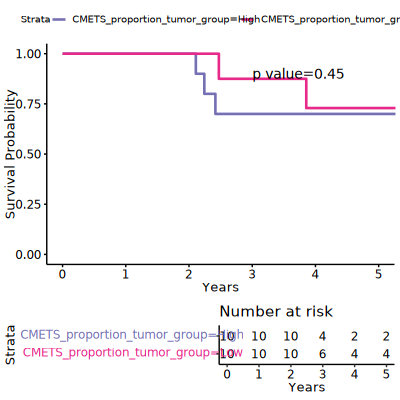

In [387]:
surv_obj <- Surv(time = liver_sample_tbl2$FU_years, event = liver_sample_tbl2$'Vital_status')

fit <- survfit(surv_obj ~ CMETS_proportion_tumor_group, data = liver_sample_tbl2)

surv_diff <- survdiff(surv_obj ~ CMETS_proportion_tumor_group, data = liver_sample_tbl2)
p_value <- round(1 - pchisq(surv_diff$chisq, df = 1), 2)

surv_plot <- ggsurvplot(fit, 
                        data = liver_sample_tbl2, 
                        palette = c("#7570B3", "#E7298A"),
                        xlab = "Years",
                        ylab = "Survival Probability",
                        xlim = c(0, 5),
                        break.x.by = 1,    
                        #ggtheme = theme_minimal(),
                        censor = FALSE,
                        risk.table = TRUE,
                        pval = paste0("p value=", p_value),
                        pval.coord = c(3, 0.9)  
                       )

set_size(4,4)
surv_plot

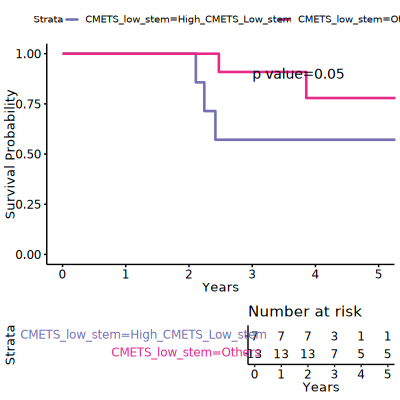

In [392]:
surv_obj <- Surv(time = liver_sample_tbl2$FU_years, event = liver_sample_tbl2$'Vital_status')

fit <- survfit(surv_obj ~ CMETS_low_stem, data = liver_sample_tbl2)

surv_diff <- survdiff(surv_obj ~ CMETS_low_stem, data = liver_sample_tbl2)
p_value <- round(1 - pchisq(surv_diff$chisq, df = 1), 2)

surv_plot <- ggsurvplot(fit, 
                        data = liver_sample_tbl2, 
                        palette = c("#7570B3", "#E7298A"),
                        xlab = "Years",
                        ylab = "Survival Probability",
                        xlim = c(0, 5),
                        break.x.by = 1,    
                        #ggtheme = theme_minimal(),
                        censor = FALSE,
                        risk.table = TRUE,
                        pval = paste0("p value=", p_value),
                        pval.coord = c(3, 0.9)  
                       )

set_size(4,4)
surv_plot

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_step()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_step()`).”


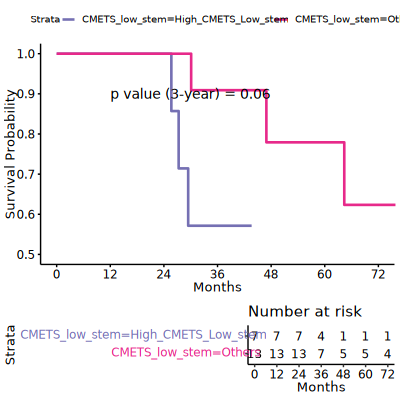

In [389]:
# Filter only patients with follow-up ≤ 36 months for the p-value calculation
pval_data <- liver_sample_tbl2 %>%
  mutate(FU_months_trunc = pmin(FU_months, 36),
         Vital_status_trunc = if_else(FU_months <= 36 & Vital_status == 1, 1, 0)
        )

# Create survival object with truncated time
surv_obj_trunc <- Surv(time = pval_data$FU_months_trunc, event = pval_data$Vital_status_trunc)

# Fit and get p-value from truncated data
surv_diff_trunc <- survdiff(surv_obj_trunc ~ CMETS_low_stem, data = pval_data)
p_value <- round(1 - pchisq(surv_diff_trunc$chisq, df = 1), 2)

# Fit survival model with original time for plotting
surv_obj_full <- Surv(time = liver_sample_tbl2$FU_months, event = liver_sample_tbl2$Vital_status)
fit <- survfit(surv_obj_full ~ CMETS_low_stem, data = liver_sample_tbl2)

# Plot full curve but show truncated p-value
surv_plot2 <- ggsurvplot(
  fit, 
  data = liver_sample_tbl2, 
  palette = c("#7570B3", "#E7298A"),
  xlab = "Months",
  ylab = "Survival Probability",
  xlim = c(0, 72),
  ylim = c(0.5, 1),  
  break.x.by = 12,    
  censor = FALSE,
  risk.table = TRUE,
  pval = paste0("p value (3-year) = ", p_value),
  pval.coord = c(12, 0.9)
)

set_size(4,4)
surv_plot2

# snRNA-seq Tumor subtype and fibroblast association

In [414]:
updated_cell_file = '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/mCRC_57_samples_clean3_metadata_cell_type_all_20260420.csv'
updated_cell = read.table(updated_cell_file, header = TRUE, sep=',', row.name=1)
head(updated_cell, 3)

,broad_cell_type,cell_type_all,cell_type_all2,cell_type_xenium,cell_type_all3,cell_type_all4
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HT112C1-T1_AAACATGCAATAATCC-1,T cell,CD4 T,CD4_Resting_T,CD4_Resting_T,CD4_Resting_T,CD4_Resting_T
HT112C1-T1_AAACCAACAGTTTCTC-1,Tumor,APCDD1+ tumor,APCDD1_CRC,APCDD1_CRC,APCDD1_CRC,APCDD1_CRC
HT112C1-T1_AAACCGCGTAAGCTTG-1,Fibroblast,Fibroblast,mesenchymal_doublets,mesenchymal_doublets,mesenchymal_doublets,mesenchymal_doublets


In [431]:
metadata_name = '/diskmnt/Projects/MetNet_analysis/Colorectal/data/snRNA_objects/57_Integrated_normalized_mCRC_snRNA_noDB_v7_clean6_metadata.csv'
metadata = read.csv(metadata_name, row.name = 1) %>% 
           select(-c(broad_cell_type, cell_type_all4))

In [433]:
idx <- match(rownames(metadata), rownames(updated_cell))

In [435]:
length(idx)

[1] 352592

In [436]:
# match by row names
idx <- match(rownames(metadata), rownames(updated_cell))

metadata$broad_cell_type <- updated_cell$broad_cell_type[idx]
metadata$cell_type_all4  <- updated_cell$cell_type_all4[idx]

In [438]:
tumor_metadata <- metadata %>% dplyr::filter(broad_cell_type == 'Tumor')
fibroblast_metadata <- metadata %>% dplyr::filter(cell_type_all4 %in% c('mCAF', 'WNT5A_BMP', 'WNT5A_infl', 'iCAF'))
tumor_fib_metadata <- metadata %>% dplyr::filter(cell_type_all4 %in% c('mCAF', 'WNT5A_BMP', 'WNT5A_infl', 'iCAF') | broad_cell_type == 'Tumor')

In [439]:
tumor_fib_count <- tumor_fib_metadata %>%
  group_by(orig.ident) %>%
  summarise(
    all_cell_count = n(),
    tumor_count = sum(broad_cell_type == "Tumor", na.rm = TRUE),
    # UPDATED: Add 'iCAF' to the total CAF count sum
    caf_count = sum(cell_type_all4 %in% c("mCAF", "WNT5A_BMP", "WNT5A_infl", "iCAF"), na.rm = TRUE), 
    CMETS_count = sum(cell_type_all4 == "CMETS", na.rm = TRUE),
    NE_count = sum(cell_type_all3 == "Neuroendocrine-like tumor", na.rm = TRUE),
    APCDD1_tumor_count = sum(cell_type_all2 == "APCDD1_CRC", na.rm = TRUE),  
    can_stem_tumor_count = sum(cell_type_all2 == "Canonical_CRC_Stem", na.rm = TRUE),
    can_stem_prolif_count = sum(cell_type_all2 == "Canonical_CRC_Stem_Proliferation", na.rm = TRUE),
    can_intestine_tumor_count = sum(cell_type_all2 == "Canonical_CRC_Intestine", na.rm = TRUE),
    can_intestine_prolif_count = sum(cell_type_all2 == "Canonical_CRC_Intestine_Proliferation", na.rm = TRUE),
    mCAF_count = sum(cell_type_all2 == "mCAF", na.rm = TRUE),
    WNT5A_BMP_count = sum(cell_type_all2 == "WNT5A_BMP", na.rm = TRUE),
    WNT5A_infl_count = sum(cell_type_all2 == "WNT5A_infl", na.rm = TRUE),
    # NEW: Add iCAF count
    iCAF_count = sum(cell_type_all2 == "iCAF", na.rm = TRUE), 
    Organ = dplyr::first(Site_of_Origin),
    Patient_ID = dplyr::first(Patient_ID),
    Primary_Side = dplyr::first(Primary_Side),
    Tx_in_6mo = dplyr::first(Tx_in_6mo),
    .groups = "drop"
  ) %>%
  filter(tumor_count > 20, caf_count > 10) %>%
  mutate(orig.ident = str_replace(orig.ident, "^HT413C1-Th1K[24]A2Nd1_2Bma1_1$", "HT413C1-Th1"))

In [440]:
unique(tumor_fib_metadata$cell_type_all4)

[1] "APCDD1_CRC"                           
 [2] "Canonical_CRC_Intestine_Proliferation"
 [3] "Canonical_CRC_Intestine"              
 [4] "CMETS"                                
 [5] "Canonical_CRC_Stem"                   
 [6] "mCAF"                                 
 [7] "Canonical_CRC_Stem_Proliferation"     
 [8] "WNT5A_BMP"                            
 [9] "iCAF"                                 
[10] "WNT5A_infl"                           
[11] "Neuroendocrine-like tumor"

In [442]:
tumor_caf_prop <- tumor_fib_count %>%
  group_by(orig.ident) %>%
  summarise(
    across(c(all_cell_count, tumor_count, caf_count,
             CMETS_count, NE_count, APCDD1_tumor_count,
             can_stem_tumor_count, can_stem_prolif_count,
             can_intestine_tumor_count, can_intestine_prolif_count,
             mCAF_count, WNT5A_BMP_count, WNT5A_infl_count,
             iCAF_count), # UPDATED: ADD iCAF_count HERE
           \(x) sum(x, na.rm = TRUE)),
    tumor_prop = round(100 * tumor_count / all_cell_count, 2),
    caf_prop = round(100 * caf_count / all_cell_count, 2),
    CMETS_prop = round(100 * CMETS_count / tumor_count, 2),
    NE_prop = round(100 * NE_count / tumor_count, 2),  
    can_stem_tumor_prop = round(100 * can_stem_tumor_count / tumor_count, 2),
    can_stem_prolif_prop = round(100 * can_stem_prolif_count / tumor_count, 2),
    can_intestine_tumor_prop = round(100 * can_intestine_tumor_count / tumor_count, 2),
    can_intestine_prolif_prop = round(100 * can_intestine_prolif_count / tumor_count, 2),
    APCDD1_tumor_prop = round(100 * APCDD1_tumor_count / tumor_count, 2),
    can_tumor_prop = round(100 * (can_stem_tumor_count + can_intestine_tumor_count) / tumor_count, 2),
    can_prolif_prop = round(100 * (can_stem_prolif_count + can_intestine_prolif_count) / tumor_count, 2),
    mCAF_prop = round(100 * mCAF_count / caf_count, 2),
    WNT5A_BMP_prop = round(100 * WNT5A_BMP_count / caf_count, 2),
    WNT5A_infl_prop = round(100 * WNT5A_infl_count / caf_count, 2),
    iCAF_prop = round(100 * iCAF_count / caf_count, 2), # NEW: iCAF prop / CAF total
    CMETS_all_prop = round(100 * CMETS_count / all_cell_count, 2),
    NE_all_prop = round(100 * NE_count / all_cell_count, 2),  
    can_stem_tumor_all_prop = round(100 * can_stem_tumor_count / all_cell_count, 2),
    can_intestine_tumor_all_prop = round(100 * can_intestine_tumor_count / all_cell_count, 2),
    can_intestine_prolif_all_prop = round(100 * can_intestine_prolif_count / all_cell_count, 2),
    mCAF_all_prop = round(100 * mCAF_count / all_cell_count, 2),
    WNT5A_BMP_all_prop = round(100 * WNT5A_BMP_count / all_cell_count, 2),
    WNT5A_infl_all_prop = round(100 * WNT5A_infl_count / all_cell_count, 2),
    iCAF_all_prop = round(100 * iCAF_count / all_cell_count, 2), # NEW: iCAF prop / ALL total
    Organ = dplyr::first(Organ),
    Patient_ID = dplyr::first(Patient_ID),
    Primary_Side = dplyr::first(Primary_Side),
    Tx_in_6mo = dplyr::first(Tx_in_6mo),
    .groups = "drop"
  )

In [461]:
colon_summary = tumor_caf_prop %>% dplyr::filter(Organ == 'colon')
liver_summary = tumor_caf_prop %>% dplyr::filter(Organ == 'liver')
lung_summary = tumor_caf_prop %>% dplyr::filter(Organ == 'lung')

organ_list <- list(
  colon = colon_summary,
  liver = liver_summary,
  lung = lung_summary
)

x_axis = c('mCAF_prop', 'WNT5A_infl_prop', 'WNT5A_BMP_prop',  'iCAF_prop')
y_axis = c('CMETS_prop', 'can_stem_tumor_prop', 'can_intestine_prolif_prop', 'can_intestine_tumor_prop')

In [462]:
colon_summary <- tumor_caf_prop %>% filter(Organ == "colon")
meta_summary  <- tumor_caf_prop %>% filter(Organ %in% c("liver", "lung"))

organ_list2 <- list(
  colon = colon_summary,
  metastasis = meta_summary
)


In [464]:
x_axis = c("mCAF_prop", "WNT5A_infl_prop", "WNT5A_BMP_prop", "iCAF_prop")
y_axis = c("CMETS_prop", "can_stem_tumor_prop",
           "can_intestine_prolif_prop", "can_intestine_tumor_prop")

In [465]:
compute_corr_matrix <- function(df, x_vars, y_vars) {
  corr_mat <- matrix(NA, nrow = length(y_vars), ncol = length(x_vars),
                     dimnames = list(y_vars, x_vars))
  p_mat <- corr_mat

  for (y in y_vars) {
    for (x in x_vars) {
      tmp <- cor.test(df[[x]], df[[y]], method = "spearman")
      corr_mat[y, x] <- tmp$estimate
      p_mat[y, x]    <- tmp$p.value
    }
  }
  return(list(corr = corr_mat, p = p_mat))
}

In [466]:
p_to_stars <- function(p) {
  ifelse(p < 0.05, "**",
         ifelse(p < 0.1, "*", ""))
}

In [467]:
col_fun = colorRamp2(
  c(-0.75, -0.5, 0, 0.5, 0.75),
  c("#2166ac", "#67a9cf", "white", "#f4a582", "#ca0020")
)

In [468]:
for (organ_name in names(organ_list2)) {

  df <- organ_list2[[organ_name]]

  # Compute correlations
  results <- compute_corr_matrix(df, x_axis, y_axis)
  corr_mat <- results$corr
  p_mat    <- results$p
  star_mat <- matrix(
    p_to_stars(p_mat),
    nrow = nrow(p_mat),
    dimnames = dimnames(p_mat)
  )

  # Prepare heatmap
  ht <- Heatmap(
    corr_mat,
    name = paste0(organ_name, "_cor"),
    col = col_fun,
    cluster_rows = FALSE,
    cluster_columns = FALSE,

    rect_gp = gpar(col = "black", lwd = 1.2),   # <-- grid lines

    cell_fun = function(j, i, x, y, w, h, fill) {
      grid.text(star_mat[i, j], x, y,
                gp = gpar(fontsize = 14, fontface = "bold"))
    },

    column_title = paste0(toupper(organ_name),
                          " – CAF vs Tumor Subtype Correlations"),
    heatmap_legend_param = list(title = "Spearman Rho")
  )

  pdf(file.path(output_dir, paste0("corr_heatmap_", organ_name, "_combined.pdf")),
      width = 6, height = 5)
  draw(ht)
  dev.off()
}

Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'COLON – CAF vs Tumor Subtype Correlations' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(df[[x]], df[[y]], method = "spearman"):
“Cannot compute exact p-value with ties”
